# Werkzeuge der Mustererkennung und des maschinellen Lernens

## Human Activity Recognition Using Smartphones Dataset

This notebook contains the complete solution for the exam tasks:
1. Load and visualize the data
2. Split the data using stratified split
3. Train k-NN and SVM with PCA features
4. Train a statistical classifier with cross-validation
5. Train a neural network using PyTorch
6. Create an ensemble classifier

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from utils import load_data
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Task 1: Load and Visualize the Data

In [2]:
# Load the data using custom parser from utils.py
X, y = load_data('WalkingSittingStanding.ts')

print(f"Data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of channels: {X.shape[1]}")
print(f"Number of timesteps: {X.shape[2]}")
print(f"\nUnique classes: {np.unique(y)}")
print(f"Class distribution:")
for cls in np.unique(y):
    count = np.sum(y == cls)
    print(f"  Class {int(cls)}: {count} samples ({count/len(y)*100:.1f}%)")

Data shape: (10299, 3, 206)
Labels shape: (10299,)
Number of samples: 10299
Number of channels: 3
Number of timesteps: 206

Unique classes: [0. 1. 2. 3. 4. 5.]
Class distribution:
  Class 0: 1722 samples (16.7%)
  Class 1: 1544 samples (15.0%)
  Class 2: 1406 samples (13.7%)
  Class 3: 1777 samples (17.3%)
  Class 4: 1906 samples (18.5%)
  Class 5: 1944 samples (18.9%)


In [3]:
# Activity labels mapping
activity_labels = {
    0.0: 'Walking',
    1.0: 'Walking Upstairs',
    2.0: 'Walking Downstairs',
    3.0: 'Sitting',
    4.0: 'Standing',
    5.0: 'Laying Down'
}

channel_names = ['Acceleration X', 'Acceleration Y', 'Acceleration Z']

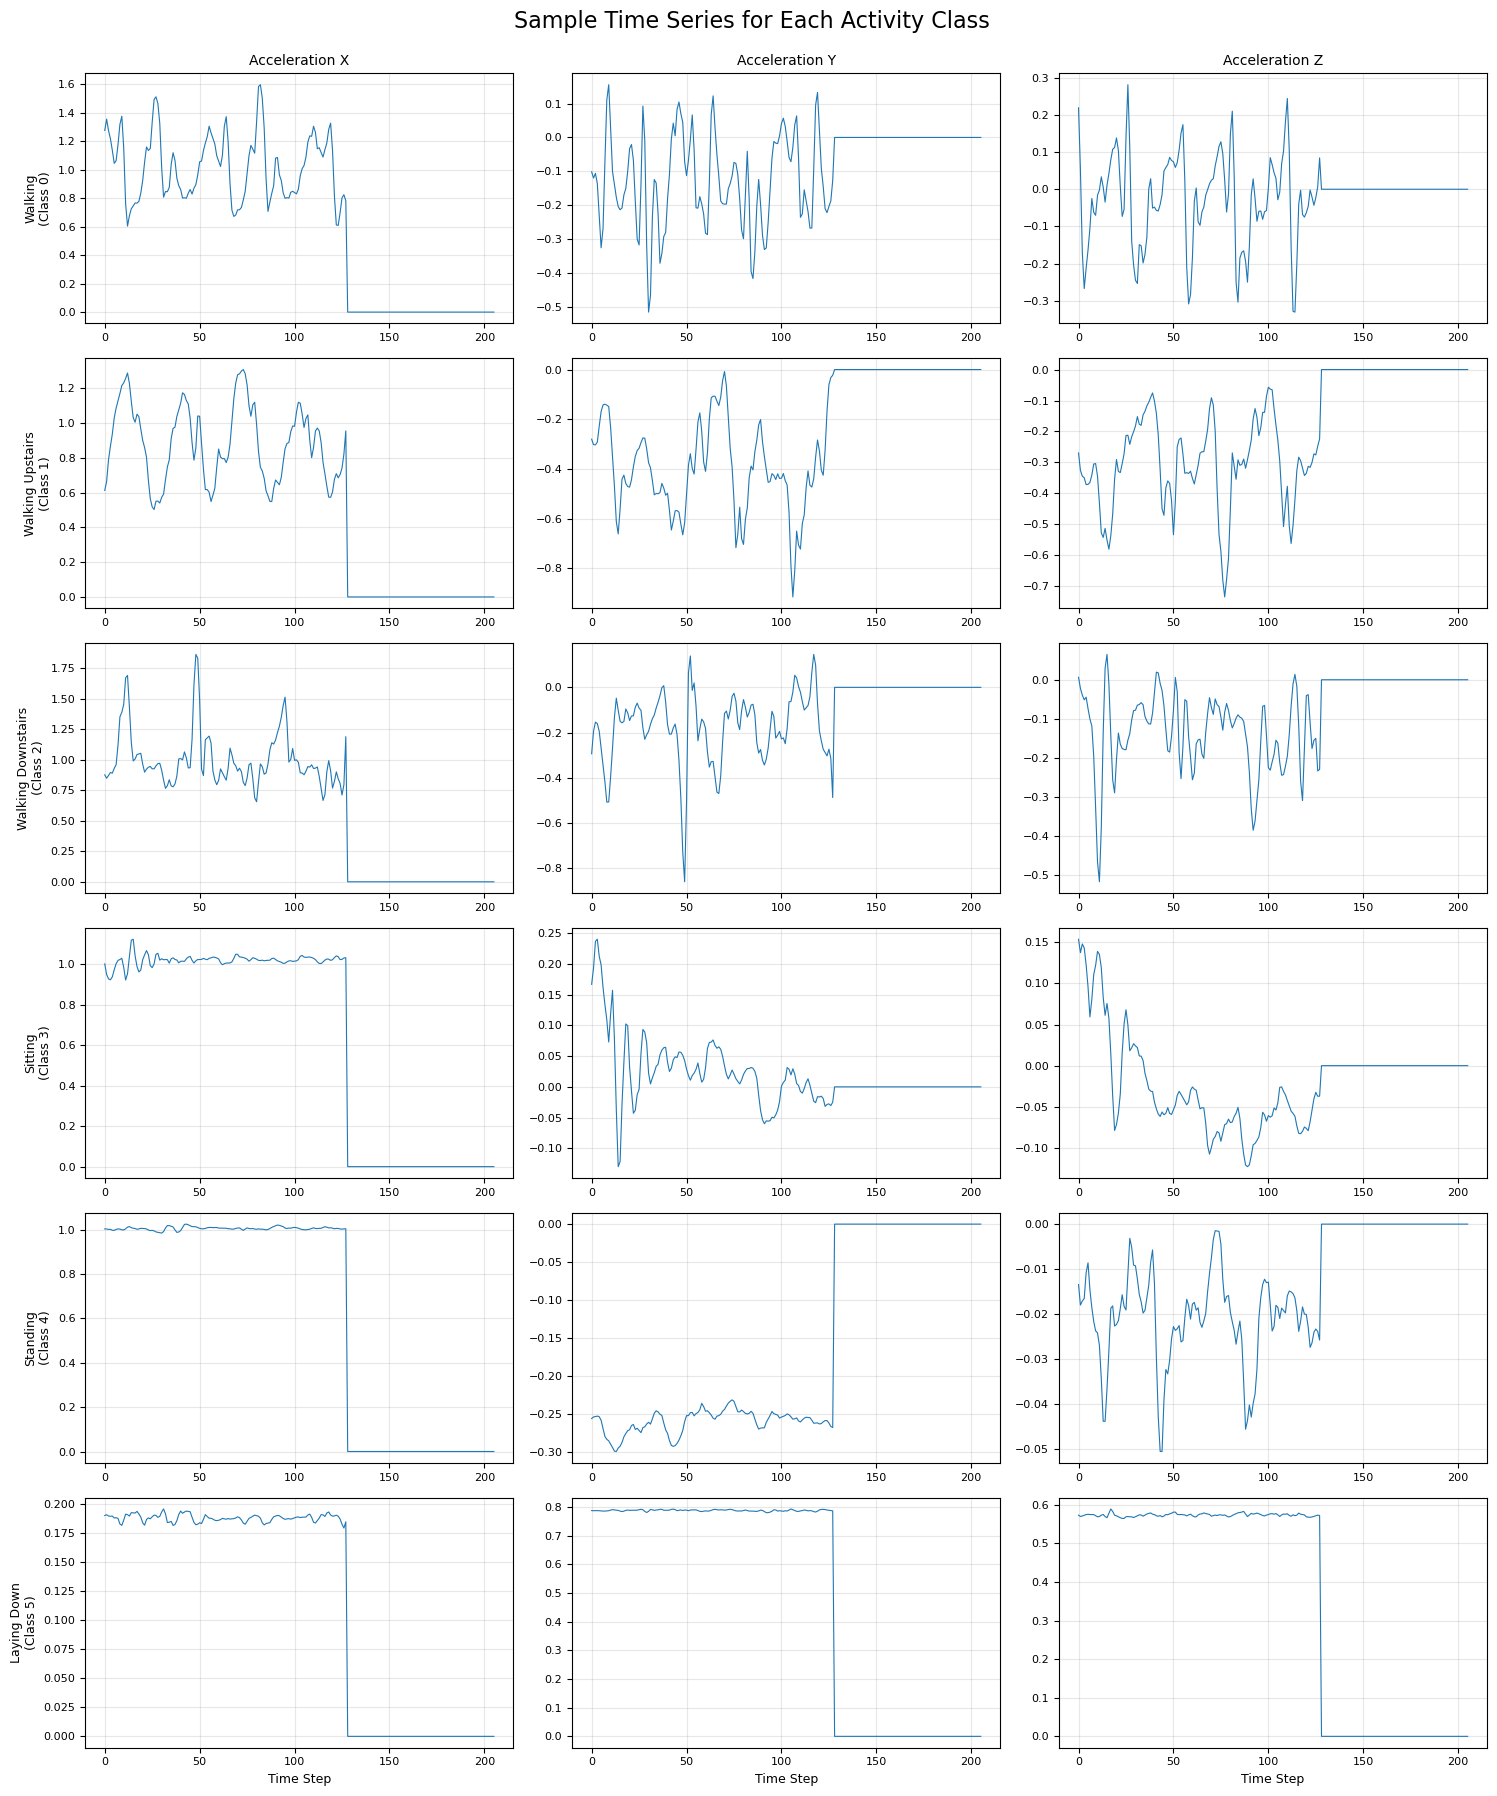

In [4]:
# Visualize sample time series for each activity class
fig, axes = plt.subplots(6, 3, figsize=(15, 18))
fig.suptitle('Sample Time Series for Each Activity Class', fontsize=16, y=0.995)

for cls_idx, cls in enumerate(np.unique(y)):
    # Get first sample of this class
    sample_idx = np.where(y == cls)[0][0]
    sample = X[sample_idx]
    
    for channel_idx in range(3):
        ax = axes[cls_idx, channel_idx]
        ax.plot(sample[channel_idx], linewidth=0.8)
        
        if cls_idx == 0:
            ax.set_title(channel_names[channel_idx], fontsize=10)
        if channel_idx == 0:
            ax.set_ylabel(f'{activity_labels[cls]}\n(Class {int(cls)})', fontsize=9)
        if cls_idx == 5:
            ax.set_xlabel('Time Step', fontsize=9)
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

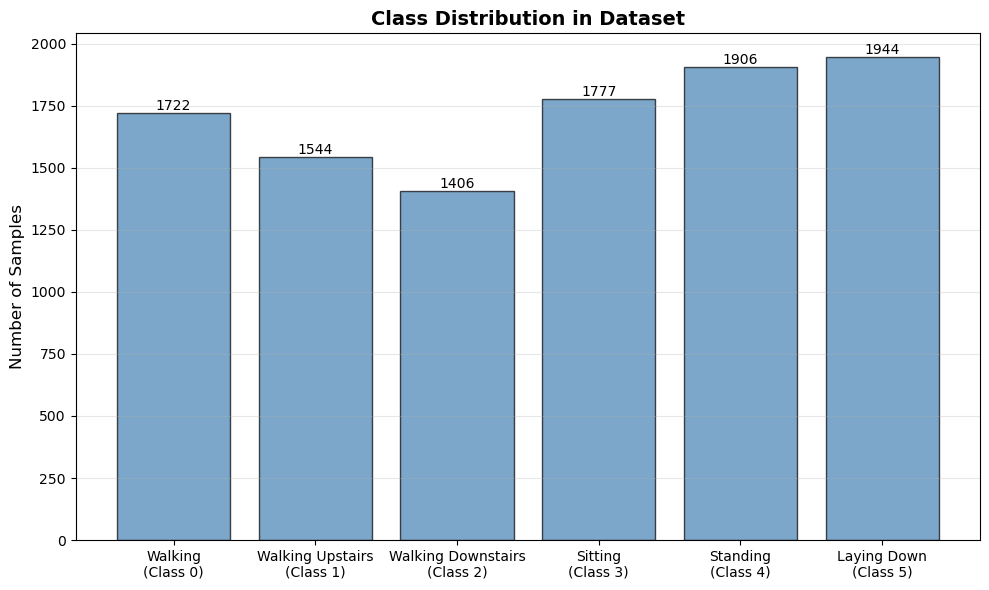

In [5]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 6))
classes, counts = np.unique(y, return_counts=True)
labels = [f"{activity_labels[cls]}\n(Class {int(cls)})" for cls in classes]

bars = ax.bar(range(len(classes)), counts, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Task 2: Split the Data Using Stratified Split

In [6]:
# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    print(f"  Class {int(cls)}: {count} samples ({count/len(y_train)*100:.1f}%)")
print(f"\nTest set class distribution:")
for cls in np.unique(y_test):
    count = np.sum(y_test == cls)
    print(f"  Class {int(cls)}: {count} samples ({count/len(y_test)*100:.1f}%)")

Training set size: 8239 samples
Test set size: 2060 samples

Training set class distribution:
  Class 0: 1378 samples (16.7%)
  Class 1: 1235 samples (15.0%)
  Class 2: 1125 samples (13.7%)
  Class 3: 1421 samples (17.2%)
  Class 4: 1525 samples (18.5%)
  Class 5: 1555 samples (18.9%)

Test set class distribution:
  Class 0: 344 samples (16.7%)
  Class 1: 309 samples (15.0%)
  Class 2: 281 samples (13.6%)
  Class 3: 356 samples (17.3%)
  Class 4: 381 samples (18.5%)
  Class 5: 389 samples (18.9%)


## Task 3: Train k-NN and SVM with PCA Features

We will flatten the time series data and apply PCA for dimensionality reduction, then train k-NN and SVM classifiers with grid search for hyperparameter optimization.

In [7]:
# Flatten the time series data for PCA
# Shape: (n_samples, n_channels * n_timesteps)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (8239, 618)
Flattened test data shape: (2060, 618)


In [8]:
# Standardize the data before PCA
# Standardization ensure equal importance of feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Apply PCA
# We'll keep 94% of variance
pca = PCA(n_components=0.94, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Number of PCA components: {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA training data shape: {X_train_pca.shape}")
print(f"PCA test data shape: {X_test_pca.shape}")

Number of PCA components: 15
Explained variance ratio: 0.9406
PCA training data shape: (8239, 15)
PCA test data shape: (2060, 15)


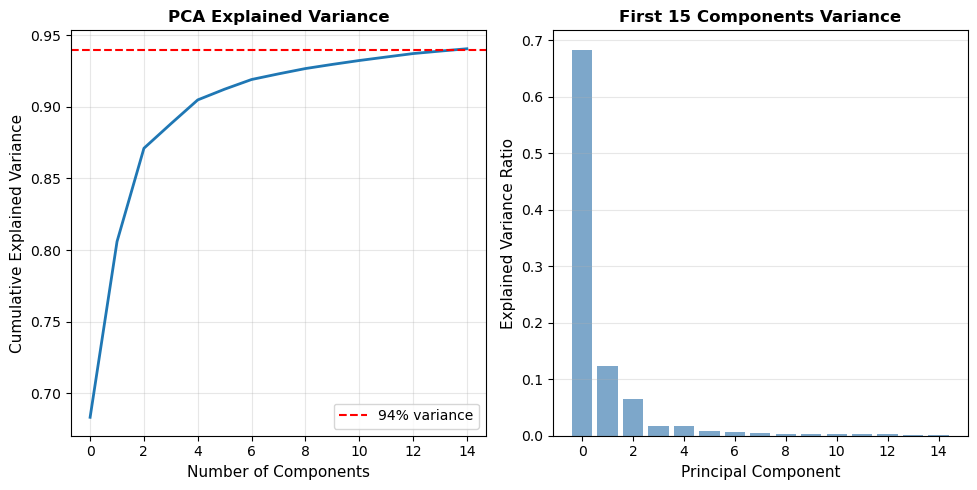

In [9]:
# Visualize explained variance
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_), linewidth=2)
plt.xlabel('Number of Components', fontsize=11)
plt.ylabel('Cumulative Explained Variance', fontsize=11)
plt.title('PCA Explained Variance', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.94, color='r', linestyle='--', label='94% variance')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(range(min(20, len(pca.explained_variance_ratio_))), 
        pca.explained_variance_ratio_[:20], alpha=0.7, color='steelblue')
plt.xlabel('Principal Component', fontsize=11)
plt.ylabel('Explained Variance Ratio', fontsize=11)
plt.title('First 15 Components Variance', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### k-NN Classifier with Grid Search

In [10]:
# Grid search for k-NN (optimizing n_neighbors)
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15, 19]}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(X_train_pca, y_train)

print(f"\nBest k-NN parameters: {knn_grid.best_params_}")
print(f"Best k-NN cross-validation score: {knn_grid.best_score_:.4f}")

# Evaluate on test set
knn_best = knn_grid.best_estimator_
y_pred_knn = knn_best.predict(X_test_pca)
knn_test_acc = accuracy_score(y_test, y_pred_knn)

print(f"k-NN test accuracy: {knn_test_acc:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best k-NN parameters: {'n_neighbors': 3}
Best k-NN cross-validation score: 0.9404
k-NN test accuracy: 0.9544


### SVM Classifier with Grid Search

In [11]:
# SVM tries to maximized margin between the classes
# Grid search for SVM (optimizing C parameter with RBF kernel)
svm_param_grid = {'C': [0.1, 1, 10, 100]}

svm = SVC(kernel='rbf', random_state=42)
svm_grid = GridSearchCV(svm, svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svm_grid.fit(X_train_pca, y_train)

print(f"\nBest SVM parameters: {svm_grid.best_params_}")
print(f"Best SVM cross-validation score: {svm_grid.best_score_:.4f}")

# Evaluate on test set
svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test_pca)
svm_test_acc = accuracy_score(y_test, y_pred_svm)

print(f"SVM test accuracy: {svm_test_acc:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best SVM parameters: {'C': 100}
Best SVM cross-validation score: 0.9347
SVM test accuracy: 0.9417


### Compare k-NN and SVM Performance


COMPARISON: k-NN vs SVM (with PCA features)
k-NN Test Accuracy: 0.9544
SVM Test Accuracy:  0.9417

Better classifier: k-NN


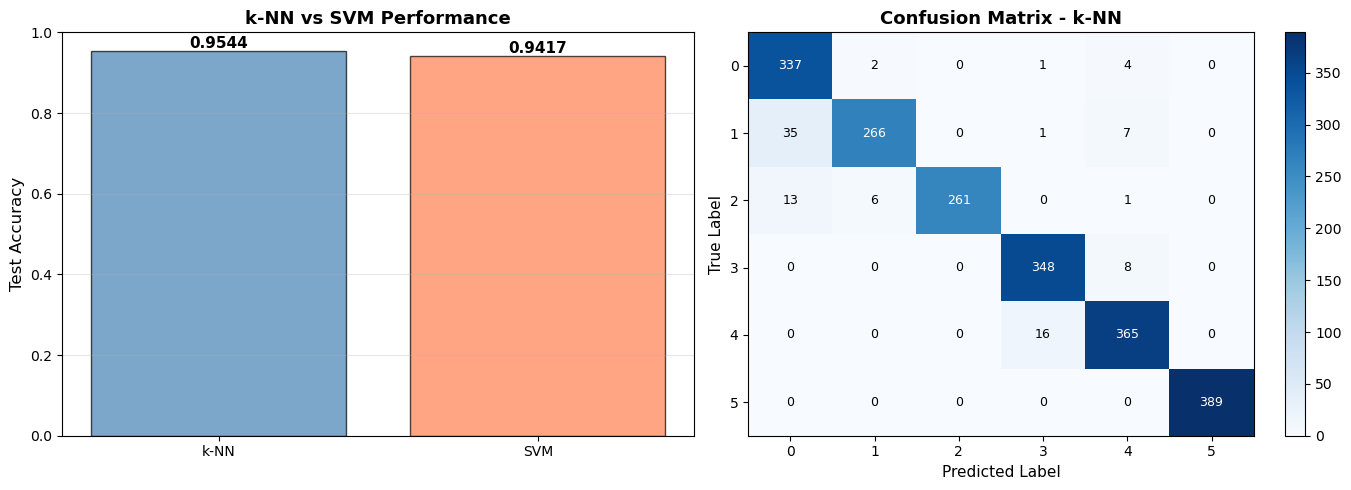

In [12]:
# Compare performance
print("\n" + "="*60)
print("COMPARISON: k-NN vs SVM (with PCA features)")
print("="*60)
print(f"k-NN Test Accuracy: {knn_test_acc:.4f}")
print(f"SVM Test Accuracy:  {svm_test_acc:.4f}")
print(f"\nBetter classifier: {'k-NN' if knn_test_acc > svm_test_acc else 'SVM'}")
print("="*60)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
ax = axes[0]
models = ['k-NN', 'SVM']
accuracies = [knn_test_acc, svm_test_acc]
colors = ['steelblue', 'coral']
bars = ax.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('k-NN vs SVM Performance', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Confusion matrix for better model
ax = axes[1]
better_pred = y_pred_knn if knn_test_acc > svm_test_acc else y_pred_svm
better_name = 'k-NN' if knn_test_acc > svm_test_acc else 'SVM'
cm = confusion_matrix(y_test, better_pred)
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title(f'Confusion Matrix - {better_name}', fontsize=13, fontweight='bold')
ax.set_xticks(range(6))
ax.set_yticks(range(6))
plt.colorbar(im, ax=ax)

# Add text annotations
for i in range(6):
    for j in range(6):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black",
                      fontsize=9)

plt.tight_layout()
plt.show()

## Task 4: Train a Statistical Classifier with Cross-Validation

We will use Gaussian Naive Bayes as our statistical classifier and perform cross-validation to visualize the variance.

In [13]:
# Train Gaussian Naive Bayes with cross-validation
# We'll use var_smoothing as the hyperparameter to optimize
gnb_param_grid = {'var_smoothing': np.logspace(-10, -8, 10)}

gnb = GaussianNB()
gnb_grid = GridSearchCV(gnb, gnb_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gnb_grid.fit(X_train_pca, y_train)

print(f"\nBest Gaussian NB parameters: {gnb_grid.best_params_}")
print(f"Best Gaussian NB cross-validation score: {gnb_grid.best_score_:.4f}")

# Evaluate on test set
gnb_best = gnb_grid.best_estimator_
y_pred_gnb = gnb_best.predict(X_test_pca)
gnb_test_acc = accuracy_score(y_test, y_pred_gnb)

print(f"Gaussian NB test accuracy: {gnb_test_acc:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Gaussian NB parameters: {'var_smoothing': np.float64(1e-10)}
Best Gaussian NB cross-validation score: 0.8221
Gaussian NB test accuracy: 0.8194


In [14]:
# Perform cross-validation for each hyperparameter value to visualize variance
cv_results = []
var_smoothing_values = np.logspace(-10, -8, 10)

for vs in var_smoothing_values:
    gnb_temp = GaussianNB(var_smoothing=vs)
    scores = cross_val_score(gnb_temp, X_train_pca, y_train, cv=5, scoring='accuracy')
    cv_results.append(scores)

cv_results = np.array(cv_results)

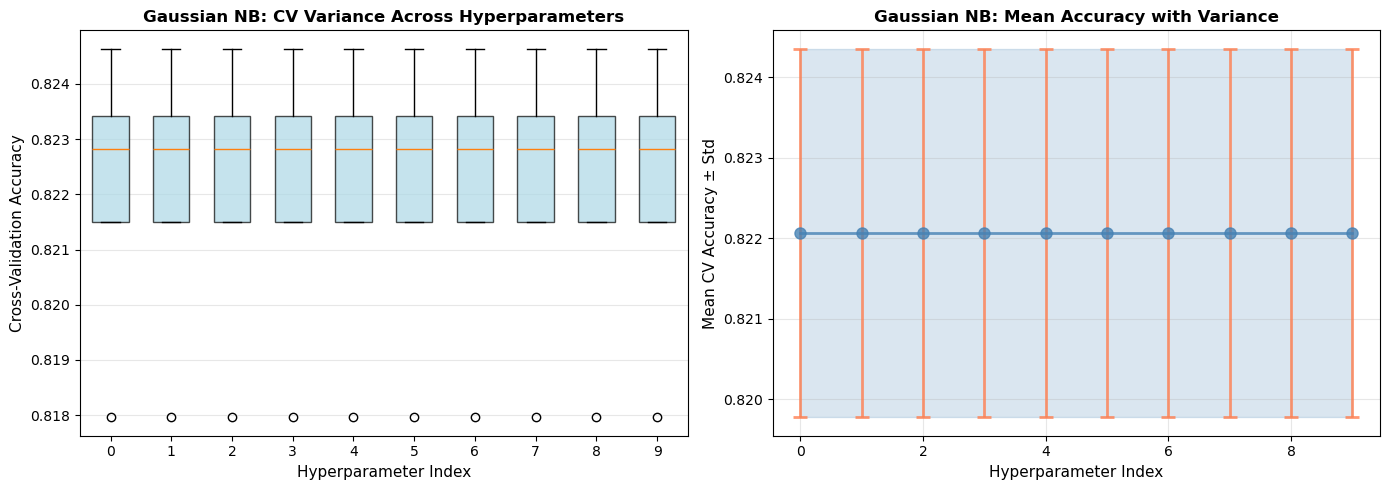


Cross-validation statistics:
Mean accuracy across all hyperparameters: 0.8221
Standard deviation across all hyperparameters: 0.0023
Best mean CV accuracy: 0.8221 (at index 0)


In [15]:
# Visualize cross-validation results with variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot showing variance across folds
ax = axes[0]
bp = ax.boxplot(cv_results.T, positions=range(len(var_smoothing_values)), 
                patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax.set_xlabel('Hyperparameter Index', fontsize=11)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=11)
ax.set_title('Gaussian NB: CV Variance Across Hyperparameters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Line plot with error bars
ax = axes[1]
means = cv_results.mean(axis=1)
stds = cv_results.std(axis=1)
x_pos = range(len(var_smoothing_values))

ax.errorbar(x_pos, means, yerr=stds, marker='o', capsize=5, capthick=2, 
            linewidth=2, markersize=8, color='steelblue', ecolor='coral', alpha=0.8)
ax.fill_between(x_pos, means - stds, means + stds, alpha=0.2, color='steelblue')
ax.set_xlabel('Hyperparameter Index', fontsize=11)
ax.set_ylabel('Mean CV Accuracy ± Std', fontsize=11)
ax.set_title('Gaussian NB: Mean Accuracy with Variance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCross-validation statistics:")
print(f"Mean accuracy across all hyperparameters: {means.mean():.4f}")
print(f"Standard deviation across all hyperparameters: {stds.mean():.4f}")
print(f"Best mean CV accuracy: {means.max():.4f} (at index {means.argmax()})")

## Task 5: Train a Neural Network Using PyTorch

We will train a 1D CNN on the original time series data (not PCA features).

In [16]:
# PyTorch Dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y.astype(int))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets and dataloaders
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 129
Test batches: 33


In [17]:
# Define 1D CNN architecture
class CNN1D(nn.Module):
    def __init__(self, n_channels=3, n_classes=6, n_timesteps=206):
        super(CNN1D, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)
        
        # Calculate size after convolutions and pooling
        # 206 -> 103 -> 51 -> 25
        self.fc_input_size = 256 * 25
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.fc_input_size, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, n_classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Conv block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)
        
        # Conv block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)
        
        # Conv block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = CNN1D().to(device)
print(f"\nModel architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cpu

Model architecture:
CNN1D(
  (conv1): Conv1d(3, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6400, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
  (relu): ReLU()
)

Total parameters: 962,054


In [18]:
# Training configuration
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training parameters
n_epochs = 30
best_val_loss = float('inf')
patience = 5
patience_counter = 0

# Track metrics
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("\nTraining configuration:")
print(f"  Epochs: {n_epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Learning rate: 0.001")
print(f"  Weight decay: 1e-4")
print(f"  Early stopping patience: {patience}")
print(f"  Dropout: 0.5")


Training configuration:
  Epochs: 30
  Batch size: 64
  Learning rate: 0.001
  Weight decay: 1e-4
  Early stopping patience: 5
  Dropout: 0.5


In [19]:
# Training loop
print("\nStarting training...\n")

for epoch in range(n_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
    
    val_loss /= len(test_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{n_epochs}] - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nTraining completed!")


Starting training...

Epoch [1/30] - Train Loss: 0.4642, Train Acc: 0.8221 | Val Loss: 0.2741, Val Acc: 0.8816
Epoch [2/30] - Train Loss: 0.2062, Train Acc: 0.9203 | Val Loss: 0.1703, Val Acc: 0.9311
Epoch [3/30] - Train Loss: 0.1762, Train Acc: 0.9291 | Val Loss: 0.1958, Val Acc: 0.9189
Epoch [4/30] - Train Loss: 0.1694, Train Acc: 0.9330 | Val Loss: 0.1269, Val Acc: 0.9515
Epoch [5/30] - Train Loss: 0.1534, Train Acc: 0.9364 | Val Loss: 0.1303, Val Acc: 0.9490
Epoch [6/30] - Train Loss: 0.1467, Train Acc: 0.9405 | Val Loss: 0.1452, Val Acc: 0.9413
Epoch [7/30] - Train Loss: 0.1339, Train Acc: 0.9437 | Val Loss: 0.1457, Val Acc: 0.9447
Epoch [8/30] - Train Loss: 0.1347, Train Acc: 0.9456 | Val Loss: 0.1313, Val Acc: 0.9485
Epoch [9/30] - Train Loss: 0.1288, Train Acc: 0.9468 | Val Loss: 0.1083, Val Acc: 0.9544
Epoch [10/30] - Train Loss: 0.1193, Train Acc: 0.9494 | Val Loss: 0.1034, Val Acc: 0.9583
Epoch [11/30] - Train Loss: 0.1169, Train Acc: 0.9533 | Val Loss: 0.1215, Val Acc: 0.9

In [20]:
# Load best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

y_pred_nn = []
y_true_nn = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        y_pred_nn.extend(predicted.cpu().numpy())
        y_true_nn.extend(batch_y.numpy())

y_pred_nn = np.array(y_pred_nn)
y_true_nn = np.array(y_true_nn)
nn_test_acc = accuracy_score(y_true_nn, y_pred_nn)

print(f"\nNeural Network test accuracy: {nn_test_acc:.4f}")


Neural Network test accuracy: 0.9636


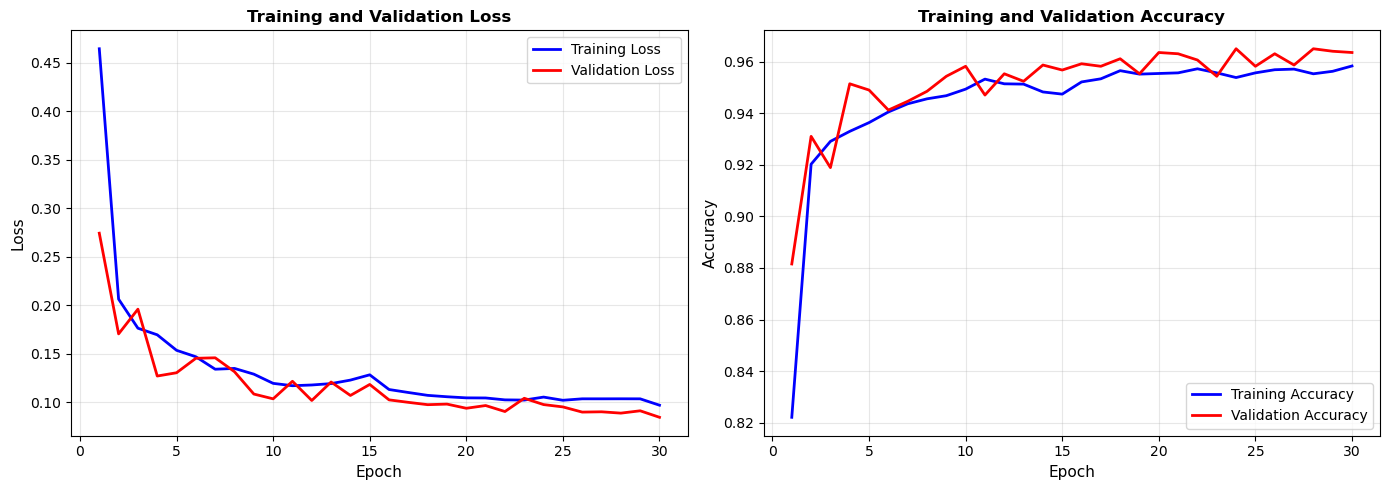

In [21]:
# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax = axes[0]
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
ax.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy plot
ax = axes[1]
ax.plot(epochs_range, train_accs, 'b-', label='Training Accuracy', linewidth=2)
ax.plot(epochs_range, val_accs, 'r-', label='Validation Accuracy', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 6: Create an Ensemble Classifier

We will combine k-NN, SVM, and Neural Network predictions using majority voting.

In [22]:
# Create ensemble predictions using majority voting
# We have: y_pred_knn, y_pred_svm, y_pred_nn

# Stack predictions
predictions_stack = np.vstack([y_pred_knn, y_pred_svm, y_pred_nn]).T

# Majority voting
from scipy import stats
y_pred_ensemble, _ = stats.mode(predictions_stack, axis=1, keepdims=False)

ensemble_test_acc = accuracy_score(y_test, y_pred_ensemble)

print(f"\nEnsemble test accuracy: {ensemble_test_acc:.4f}")


Ensemble test accuracy: 0.9592


In [23]:
# Compare all classifiers
print("\n" + "="*70)
print("FINAL COMPARISON: All Classifiers")
print("="*70)
print(f"k-NN (with PCA):              {knn_test_acc:.4f}")
print(f"SVM (with PCA):               {svm_test_acc:.4f}")
print(f"Gaussian Naive Bayes (PCA):   {gnb_test_acc:.4f}")
print(f"Neural Network (CNN):         {nn_test_acc:.4f}")
print(f"Ensemble (k-NN + SVM + NN):   {ensemble_test_acc:.4f}")
print("="*70)

# Determine best classifier
all_accs = {
    'k-NN': knn_test_acc,
    'SVM': svm_test_acc,
    'Gaussian NB': gnb_test_acc,
    'Neural Network': nn_test_acc,
    'Ensemble': ensemble_test_acc
}
best_classifier = max(all_accs, key=all_accs.get)
print(f"\nBest classifier: {best_classifier} with accuracy {all_accs[best_classifier]:.4f}")

# Check if ensemble is better than individual classifiers
individual_best = max(knn_test_acc, svm_test_acc, nn_test_acc)
if ensemble_test_acc > individual_best:
    print(f"✓ Ensemble is better than the best individual classifier!")
    print(f"  Improvement: {(ensemble_test_acc - individual_best)*100:.2f}%")
else:
    print(f"✗ Ensemble is not better than the best individual classifier.")
    print(f"  Difference: {(ensemble_test_acc - individual_best)*100:.2f}%")


FINAL COMPARISON: All Classifiers
k-NN (with PCA):              0.9544
SVM (with PCA):               0.9417
Gaussian Naive Bayes (PCA):   0.8194
Neural Network (CNN):         0.9636
Ensemble (k-NN + SVM + NN):   0.9592

Best classifier: Neural Network with accuracy 0.9636
✗ Ensemble is not better than the best individual classifier.
  Difference: -0.44%


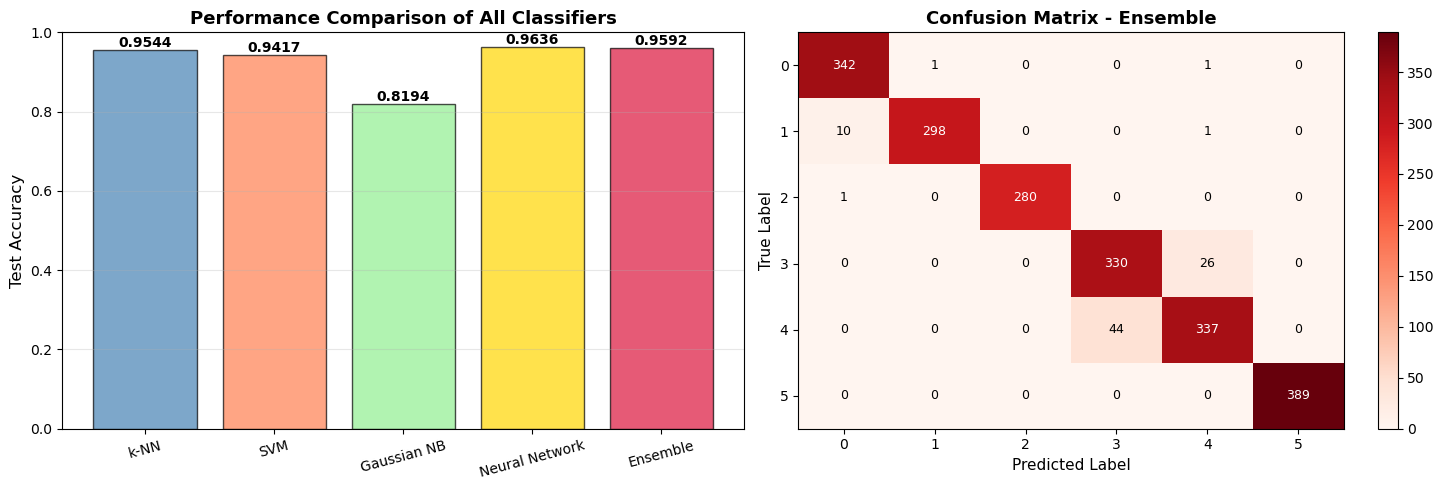

In [24]:
# Visualize final comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of all classifiers
ax = axes[0]
classifiers = list(all_accs.keys())
accuracies = list(all_accs.values())
colors = ['steelblue', 'coral', 'lightgreen', 'gold', 'crimson']
bars = ax.bar(classifiers, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Performance Comparison of All Classifiers', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Confusion matrix for ensemble
ax = axes[1]
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
im = ax.imshow(cm_ensemble, cmap='Reds', aspect='auto')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix - Ensemble', fontsize=13, fontweight='bold')
ax.set_xticks(range(6))
ax.set_yticks(range(6))
plt.colorbar(im, ax=ax)

for i in range(6):
    for j in range(6):
        text = ax.text(j, i, cm_ensemble[i, j],
                      ha="center", va="center", 
                      color="white" if cm_ensemble[i, j] > cm_ensemble.max()/2 else "black",
                      fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
# Detailed classification report for ensemble
print("\nDetailed Classification Report - Ensemble:")
print("="*70)
print(classification_report(y_test, y_pred_ensemble, 
                          target_names=[activity_labels[float(i)] for i in range(6)]))


Detailed Classification Report - Ensemble:
                    precision    recall  f1-score   support

           Walking       0.97      0.99      0.98       344
  Walking Upstairs       1.00      0.96      0.98       309
Walking Downstairs       1.00      1.00      1.00       281
           Sitting       0.88      0.93      0.90       356
          Standing       0.92      0.88      0.90       381
       Laying Down       1.00      1.00      1.00       389

          accuracy                           0.96      2060
         macro avg       0.96      0.96      0.96      2060
      weighted avg       0.96      0.96      0.96      2060



## Summary

Exam tasks:

1. **Data Loading & Visualization**: Loaded 10,299 samples with 3 channels and 206 timesteps, visualized time series patterns for each activity class.

2. **Stratified Split**: Split data into 80% training and 20% test sets while maintaining class distribution.

3. **k-NN & SVM with PCA**: Applied PCA for dimensionality reduction, performed grid search for hyperparameter optimization, and compared performance.

4. **Statistical Classifier**: Trained Gaussian Naive Bayes with cross-validation and visualized variance across different hyperparameters.

5. **Neural Network**: Implemented a 1D CNN architecture with batch normalization, dropout, and early stopping on original time series data.

6. **Ensemble**: Combined k-NN, SVM, and Neural Network using majority voting to potentially improve overall performance.

All models were evaluated on the same test set to ensure fair comparison.